##### Cellule 1 : Imports & chargement du modèle

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
shap.initjs()

# Charger le modèle sauvegardé
m_final = joblib.load('../models/xgboost_grocery1_store1.pkl')

# Reconstruire X_test (copier cellule 1 du notebook 03)
import sys
sys.path.append('..')
from src.data_loader import load_data
from src.feature_engineering import build_features

df = load_data('../data/')
d_clean = build_features(df, store_nbr=1, family='GROCERY I')

FEAT_COLS = [c for c in d_clean.columns if c != 'sales']
split = int(len(d_clean) * 0.8)
X_test  = d_clean[FEAT_COLS].iloc[split:]
y_test  = d_clean['sales'].iloc[split:]

print(f"Modèle chargé · {len(X_test)} jours de test · {len(FEAT_COLS)} features")

c:\Users\dosse\Desktop\20_Projet_LinkdIn\Projet_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[build_features] 1 · GROCERY I
  Lignes avant dropna : 1714
  Lignes après dropna : 1686
  Features construites : 37
Modèle chargé · 338 jours de test · 37 features


##### Cellule 2 : SHAP — Calcul des valeurs

In [2]:

explainer = shap.TreeExplainer(m_final)
shap_values = explainer(X_test)

print(f"Shape SHAP values : {shap_values.values.shape}")
print(f"(lignes × features = {X_test.shape[0]} × {X_test.shape[1]})")

Shape SHAP values : (338, 37)
(lignes × features = 338 × 37)


##### Cellule 3 : Summary plot — Vue globale

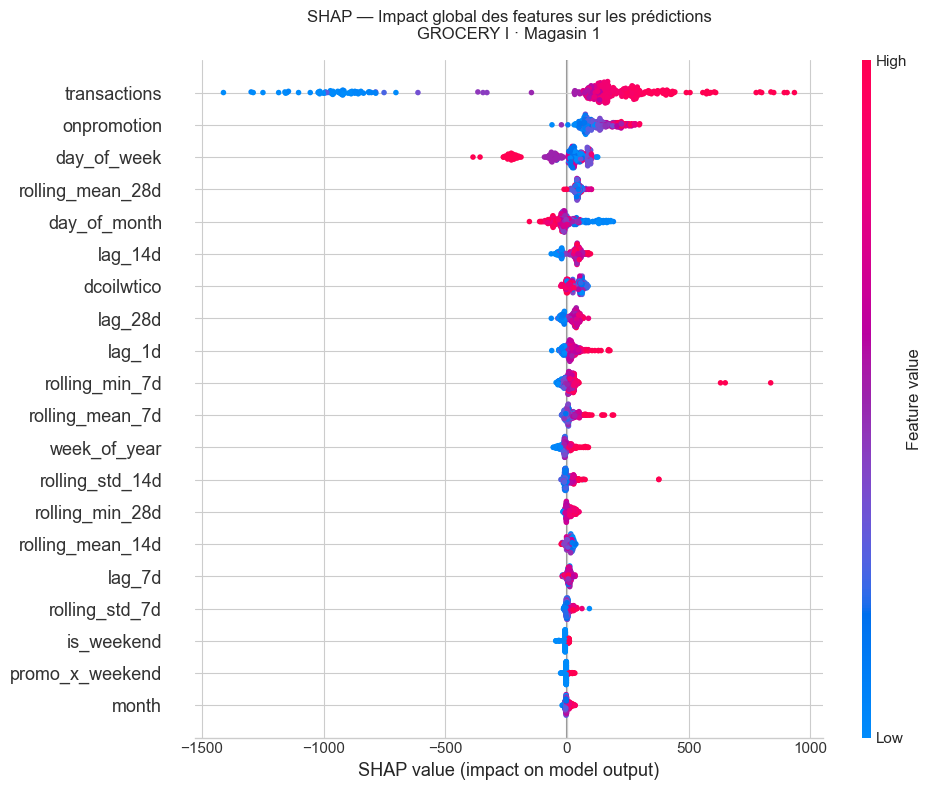

In [3]:

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    max_display=20,
    show=False,
    plot_size=None
)
ax = plt.gca()
ax.set_title('SHAP — Impact global des features sur les prédictions\nGROCERY I · Magasin 1',
             fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('../shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

##### Cellule 4 : Bar plot — Importance moyenne absolue

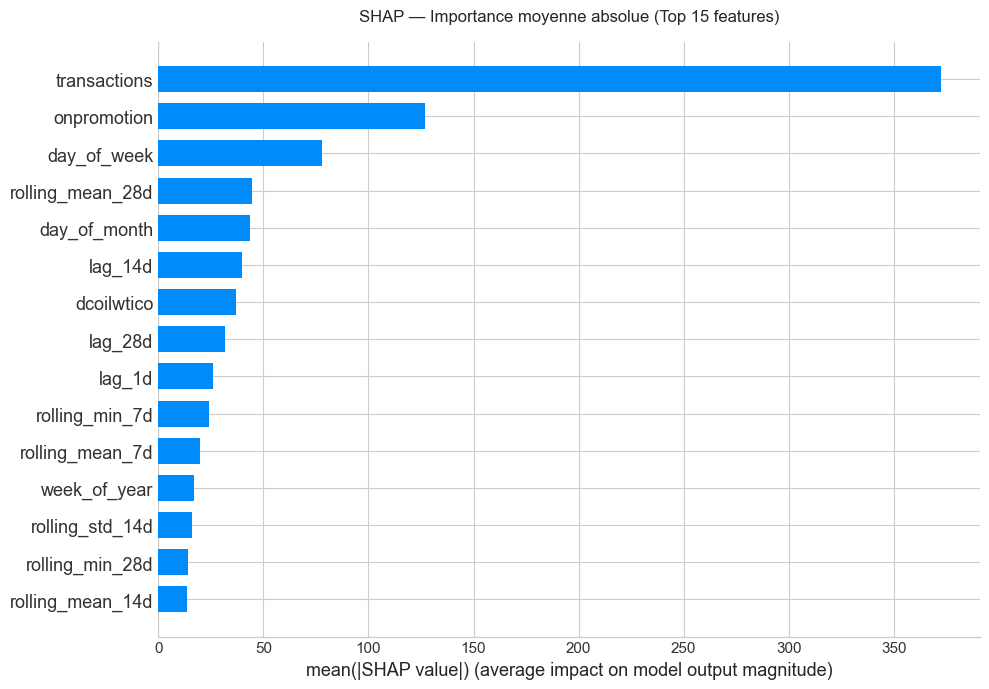

In [4]:

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    max_display=15,
    show=False,
    plot_size=None
)
ax = plt.gca()
ax.set_title('SHAP — Importance moyenne absolue (Top 15 features)',
             fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('../shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

##### Cellule 5 : Dependence plots — 3 features clés

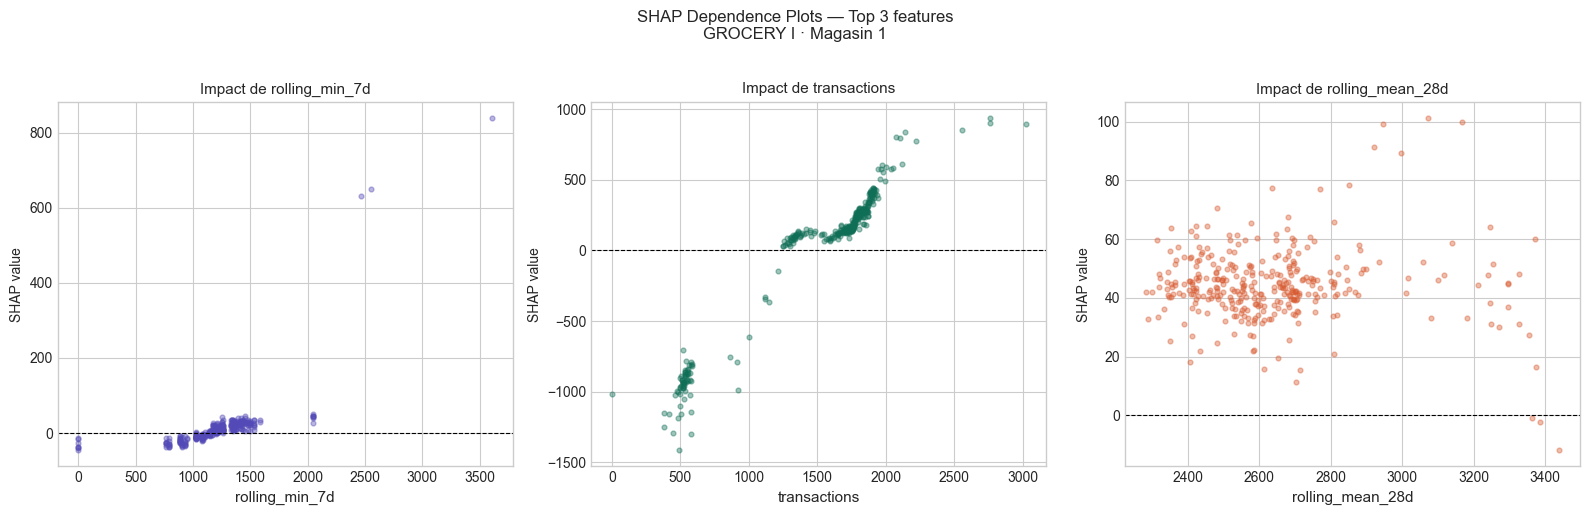

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

top3 = ['rolling_min_7d', 'transactions', 'rolling_mean_28d']
colors = ['#534AB7', '#0F6E56', '#D85A30']

for i, feat in enumerate(top3):
    feat_idx = list(X_test.columns).index(feat)
    axes[i].scatter(
        X_test[feat],
        shap_values.values[:, feat_idx],
        alpha=0.4, s=12, color=colors[i]
    )
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('SHAP value', fontsize=10)
    axes[i].set_title(f'Impact de {feat}', fontsize=11)

plt.suptitle('SHAP Dependence Plots — Top 3 features\nGROCERY I · Magasin 1',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()

##### Cellule 6 : Waterfall — Explication d'une prédiction individuelle

Pire prédiction  — Jour : 2017-03-07
  Réel : 4917 · Prédit : 2772

Meilleure prédiction — Jour : 2017-04-20
  Réel : 2546 · Prédit : 2544


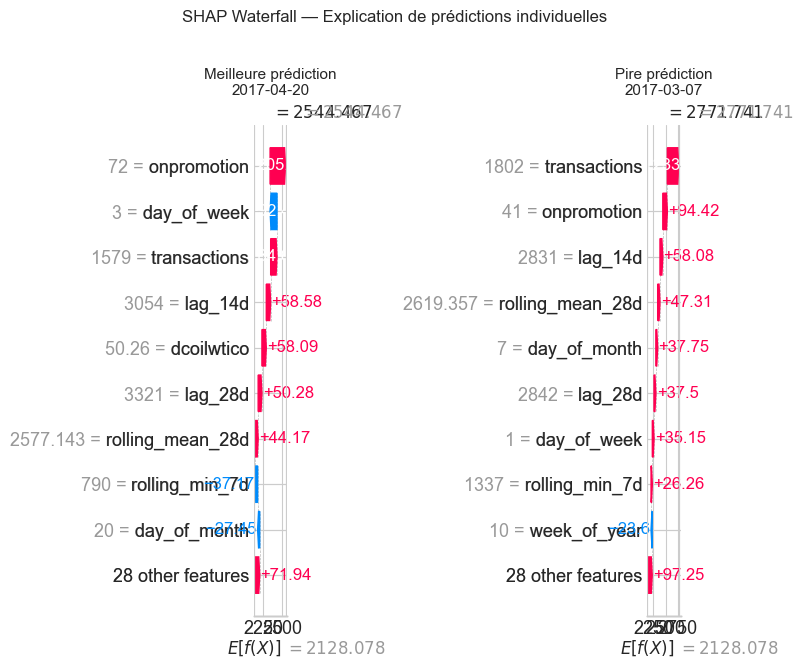

In [6]:

# Choisir le jour avec la plus grande erreur de prédiction
pred_test = m_final.predict(X_test)
errors = np.abs(y_test.values - pred_test)
worst_idx = np.argmax(errors)
best_idx  = np.argmin(errors)

print(f"Pire prédiction  — Jour : {X_test.index[worst_idx].date()}")
print(f"  Réel : {y_test.values[worst_idx]:.0f} · Prédit : {pred_test[worst_idx]:.0f}")
print(f"\nMeilleure prédiction — Jour : {X_test.index[best_idx].date()}")
print(f"  Réel : {y_test.values[best_idx]:.0f} · Prédit : {pred_test[best_idx]:.0f}")

# Waterfall pour la meilleure prédiction
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.waterfall_plot(shap_values[best_idx], max_display=10, show=False)
axes[0].set_title(f'Meilleure prédiction\n{X_test.index[best_idx].date()}', fontsize=11)

plt.sca(axes[1])
shap.waterfall_plot(shap_values[worst_idx], max_display=10, show=False)
axes[1].set_title(f'Pire prédiction\n{X_test.index[worst_idx].date()}', fontsize=11)

plt.suptitle('SHAP Waterfall — Explication de prédictions individuelles',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

##### Cellule 7 : Récapitulatif des insights SHAP

In [8]:

shap_df = pd.DataFrame(
    np.abs(shap_values.values),
    columns=X_test.columns
)
mean_shap = shap_df.mean().sort_values(ascending=False)

print("═" * 50)
print("TOP 10 FEATURES — Impact moyen sur les prédictions")
print("═" * 50)
for i, (feat, val) in enumerate(mean_shap.head(10).items(), 1):
    bar = '█' * int(val / mean_shap.max() * 20)
    print(f"{i:>2}. {feat:<25} {bar} {val:.1f}")

print(f"\n→ Les features de mémoire récente (rolling) dominent")
print(f"→ Le trafic client (transactions) > les promotions")
print(f"→ Les features d'interaction ont un impact limité sur GROCERY I")

══════════════════════════════════════════════════
TOP 10 FEATURES — Impact moyen sur les prédictions
══════════════════════════════════════════════════
 1. transactions              ████████████████████ 373.8
 2. onpromotion               ██████ 128.9
 3. day_of_week               ████ 77.5
 4. rolling_mean_28d          ██ 46.9
 5. day_of_month              ██ 43.4
 6. lag_14d                   ██ 41.2
 7. dcoilwtico                █ 37.3
 8. lag_28d                   █ 34.7
 9. lag_1d                    █ 29.2
10. rolling_min_7d            █ 23.6

→ Les features de mémoire récente (rolling) dominent
→ Le trafic client (transactions) > les promotions
→ Les features d'interaction ont un impact limité sur GROCERY I
